## Setup

In [1]:
%load_ext autoreload

%autoreload 2

In [2]:
# !pip install -r ../requirements.txt

In [3]:
import sys
sys.path.append('../')

In [4]:
import random
import time
import warnings
from datetime import datetime
import seaborn as sns
import torch

import numpy as np

import matplotlib.pyplot as plt
# from scripts.differentiable_pfn_evaluation import eval_model_range
from scripts.model_builder import get_model, get_default_spec, save_model, load_model
from scripts.transformer_prediction_interface import transformer_predict, get_params_from_config, load_model_workflow

from scripts.model_configs import *

from datasets import load_openml_list, open_cc_dids, open_cc_valid_dids
from priors.utils import plot_prior, plot_features
from priors.utils import uniform_int_sampler_f

from priors.ate_wrapper import get_batch_ate

from scripts.tabular_metrics import calculate_score_per_method, calculate_score
# from scripts.tabular_evaluation import evaluate

from priors.differentiable_prior import DifferentiableHyperparameterList, draw_random_style, merge_style_with_info
from scripts import tabular_metrics
from notebook_utils import *

In [5]:
large_datasets = True
max_samples = 10000 if large_datasets else 5000
bptt = 10000 if large_datasets else 3000
suite='cc'

In [6]:
device = 'cpu'
base_path = '.'
max_features = 100

In [7]:
def print_models(model_string):
    print(model_string)

    for i in range(80):
        for e in range(50):
            exists = Path(os.path.join(base_path, f'models_diff/prior_diff_real_checkpoint{model_string}_n_{i}_epoch_{e}.cpkt')).is_file()
            if exists:
                print(os.path.join(base_path, f'models_diff/prior_diff_real_checkpoint{model_string}_n_{i}_epoch_{e}.cpkt'))
        print()

In [8]:
def train_function(config_sample, i, add_name=''):
    start_time = time.time()
    N_epochs_to_save = 50
    
    def save_callback(model, epoch):
        if not hasattr(model, 'last_saved_epoch'):
            model.last_saved_epoch = 0
        if ((time.time() - start_time) / (maximum_runtime * 60 / N_epochs_to_save)) > model.last_saved_epoch:
            print('Saving model..')
            config_sample['epoch_in_training'] = epoch
            save_model(model, base_path, f'models_diff/prior_diff_real_checkpoint{add_name}_n_{i}_epoch_{model.last_saved_epoch}.cpkt',
                           config_sample)
            model.last_saved_epoch = model.last_saved_epoch + 1 # TODO: Rename to checkpoint
    
    model = get_model(config_sample
                      , device
                      , should_train=True
                      , verbose=1
                      , epoch_callback = save_callback)
    
    return

## Define prior settings

In [9]:
def reload_config(config_type='causal', task_type='multiclass', longer=0):
    config = get_prior_config(config_type=config_type)
    
    config['prior_type'], config['differentiable'], config['flexible'] = 'prior_bag', True, True
    
    model_string = ''
    
    config['epochs'] = 12000
    config['recompute_attn'] = True

    config['max_num_classes'] = 10
    config['num_classes'] = uniform_int_sampler_f(2, config['max_num_classes'])
    config['balanced'] = False
    model_string = model_string + '_multiclass'
    
    model_string = model_string + '_'+datetime.now().strftime("%m_%d_%Y_%H_%M_%S")
    
    return config, model_string

## Visualize Prior samples

In [10]:
config, model_string = reload_config(longer=1)

config['bptt_extra_samples'] = None

# diff
config['output_multiclass_ordered_p'] = 0.
del config['differentiable_hyperparameters']['output_multiclass_ordered_p']

config['multiclass_type'] = 'rank'
del config['differentiable_hyperparameters']['multiclass_type']

config['sampling'] = 'normal' # vielleicht schlecht?
del config['differentiable_hyperparameters']['sampling']

config['pre_sample_causes'] = True
# end diff

config['multiclass_loss_type'] = 'nono' # 'compatible'
config['normalize_to_ranking'] = False # False

config['categorical_feature_p'] = .2 # diff: .0

# turn this back on in a random search!?
config['nan_prob_no_reason'] = .0
config['nan_prob_unknown_reason'] = .0 # diff: .0
config['set_value_to_nan'] = .1 # diff: 1.

config['normalize_with_sqrt'] = False

config['new_mlp_per_example'] = True
config['prior_mlp_scale_weights_sqrt'] = True
config['batch_size_per_gp_sample'] = None

config['normalize_ignore_label_too'] = False

config['differentiable_hps_as_style'] = False
config['max_eval_pos'] = 1000

config['random_feature_rotation'] = True
config['rotate_normalized_labels'] = True

config["mix_activations"] = False # False heisst eig True

config['emsize'] = 512
config['nhead'] = config['emsize'] // 128
config['bptt'] = 1024+128
config['canonical_y_encoder'] = False

    
config['aggregate_k_gradients'] = 8
config['batch_size'] = 8*config['aggregate_k_gradients']
config['num_steps'] = 1024//config['aggregate_k_gradients']
config['epochs'] = 400
config['total_available_time_in_s'] = None #60*60*22 # 22 hours for some safety...

config['train_mixed_precision'] = True
config['efficient_eval_masking'] = True

config_sample = evaluate_hypers(config)

Using style prior: True
MODEL BUILDER <module 'priors.differentiable_prior' from '/Users/valik/LMU-PhD/Causal-Foundation-Models/TabPFNPrediction/TabPFN/priors/differentiable_prior.py'> <function get_model.<locals>.make_get_batch.<locals>.new_get_batch at 0x12b24c310>
Using cpu:0 device
init dist
Not using distributed
DataLoader.__dict__ {'num_steps': 1024, 'get_batch_kwargs': {'batch_size': 1, 'eval_pos_seq_len_sampler': <function train.<locals>.eval_pos_seq_len_sampler at 0x12b24c5e0>, 'seq_len_maximum': 1152, 'device': 'cpu:0', 'num_features': 100, 'hyperparameters': {'lr': 0.000140110642626313, 'dropout': 0.0, 'emsize': 512, 'batch_size': 1, 'nlayers': 12, 'num_features': 100, 'nhead': 4, 'nhid_factor': 2, 'bptt': 1152, 'eval_positions': None, 'seq_len_used': 50, 'sampling': 'normal', 'epochs': 400, 'num_steps': 1024, 'verbose': True, 'mix_activations': False, 'pre_sample_causes': True, 'multiclass_type': 'rank', 'nan_prob_unknown_reason_reason_prior': 0.5, 'categorical_feature_p': 

/Users/valik/.pyenv/versions/3.10.1/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/valik/.pyenv/versions/3.10.1/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


<Figure size 800x800 with 0 Axes>

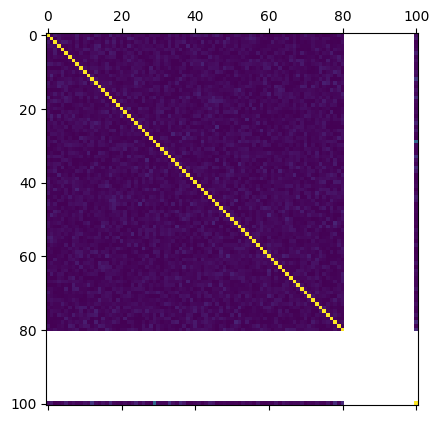

In [11]:
config_sample['batch_size'] = 4
model = get_model(config_sample, device, should_train=False, verbose=2) # , state_dict=model[2].state_dict()
(hp_embedding, data, _), targets, single_eval_pos = next(iter(model[3]))

from utils import normalize_data
fig = plt.figure(figsize=(8, 8))
N = 100
# plot_features(data[0:N, 0, 0:4], targets[0:N, 0], fig=fig)

d = np.concatenate([data[:, 0, :].T, np.expand_dims(targets[:, 0], -1).T])
d[np.isnan(d)] = 0
c = np.corrcoef(d)
plt.matshow(np.abs(c), vmin=0, vmax=1)
plt.show()

## Training

In [12]:
# model = get_model(config_sample, device, should_train=True, verbose=0)

In [13]:
from TabPFN.scripts.model_configs import get_prior_config
import torch

# Pick the same family you used in the notebook; 'causal' is natural for treatment effects
cfg = get_prior_config('causal')   # returns a config dict incl. differentiable hyperparams knobs
# You can also tweak cfg['differentiable_hyperparameters'] before sampling if you like. :contentReference[oaicite:1]{index=1}

num_features = 10

# Minimal concrete hyperparameters passed to the prior:
hparams = {
    # typical values in the notebook; adjust to match your earlier cells
    "num_layers": 3,
    "prior_mlp_hidden_dim": 64,
    "noise_std": 0.05,
    "init_std": 1.0,
    "is_causal": True,
    "num_causes": num_features,
    "y_is_effect": True,
    "pre_sample_weights": True,
    "pre_sample_causes": True,
    "sampling": "normal",
    "prior_mlp_activations": torch.nn.Tanh,
    "block_wise_dropout": False,
    "sort_features": False,
    "in_clique": False
}

hparams.setdefault("prior_mlp_scale_weights_sqrt", True)
hparams.setdefault("new_mlp_per_example", True)
hparams.setdefault("normalize_with_sqrt", False)
hparams.setdefault("prior_mlp_dropout_prob", 0.0)
hparams.setdefault("block_wise_dropout", False)
hparams.setdefault("sort_features", False)
hparams.setdefault("in_clique", False)

hparams.setdefault("random_feature_rotation", False)   # <- add this
hparams.setdefault("random_feature_rotation_std", 0.0) # optional companion knob

0.0

In [14]:
from matplotlib import rc
import matplotlib as mpl
rc('font',**{'family':'libertine'})
rc('text', usetex=True)
# rc('pgf', texsystem='pdflatex', rcfonts=False)
rc('text.latex', preamble=r'\usepackage{scalerel,stackengine,amsmath,amsfonts}')

FIGURES_PATH = '../../../../Dropbox/Програми/Overleaf/Frequentist Consistency of (causal) PFNs (ICML)/figures/'

In [15]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import seaborn as sns
import pandas as pd

sample_name = r"Amount of measured confounding, $\Delta$"
dim_cov_name = r"$d_x$"

5
Simpsons parasox measure (features = 5): 0.03923569619655609


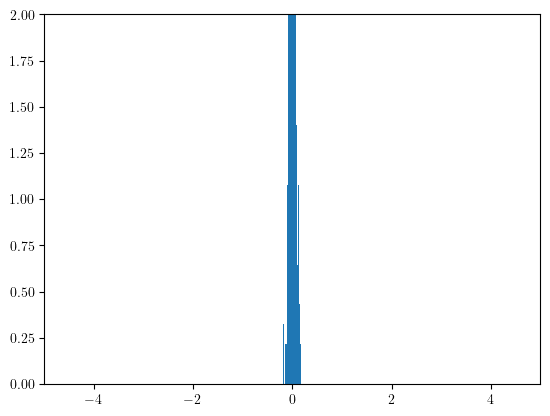

50
Simpsons parasox measure (features = 50): 0.06465217471122742


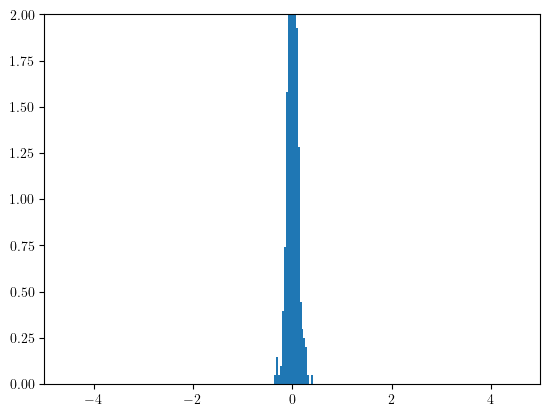

100
Simpsons parasox measure (features = 100): 0.0582994669675827


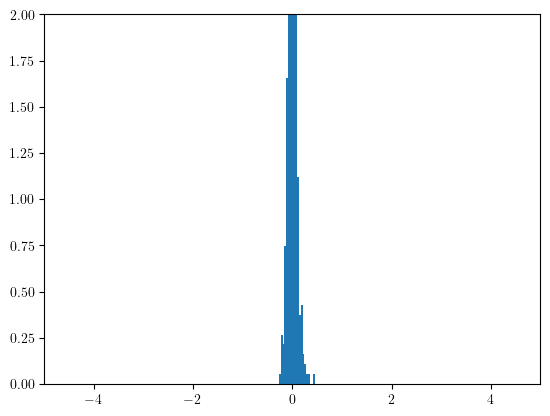

In [16]:
# Draw a batch
dfs = []

num_features_list = [5, 50, 100]

for num_features in num_features_list:

    hparams.setdefault("num_causes", num_features)
    X, A, Y0, Y1, Y, PS = get_batch_ate(
        batch_size=512,    # number of independent datasets per call
        seq_len=10000,      # rows per dataset
        num_features=num_features,
        hyperparameters=hparams,
        treat_model="mlp",
        treat_scale=0.6,
        seed=0,
    )

    # print("Shapes: X", X.shape, "A", A.shape, "Y0", Y0.shape, "Y1", Y1.shape, "Y", Y.shape, "PS", PS.shape)
    # print("Empirical ATE in this draw:", (Y1 - Y0).mean().item())
    # print("Empirical means diff:", (Y[A == 1].mean().item() - Y[A == 0].mean().item()))

    ates = (Y1/Y.std(0, keepdims=True) - Y0/Y.std(0, keepdims=True)).mean(0)
    means_diff = ((A * Y/Y.std(0, keepdims=True)).sum(0) / A.sum(0)) - (((1.0 - A) * Y/Y.std(0, keepdims=True)).sum(0) / (1.0 - A).sum(0))

    difss = ates - means_diff 
    difss = difss[~difss.isnan()]
    difss = difss[(difss > -5.0) & (difss < 5.0)]

    # print("Average propensity:", PS.mean().item())

    print(f"Simpsons parasox measure (features = {num_features}):", (difss).abs().nanmean().item())

    plt.hist(difss, density=True, bins=20)
    plt.xlim(-5, 5)
    plt.ylim(0, 2.0)
    plt.show()

    dfs.append(pd.DataFrame({'sample': difss}))

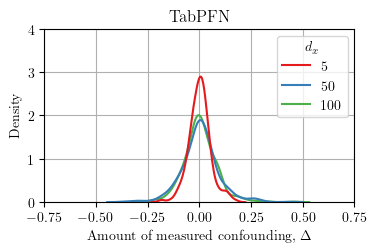

In [19]:
df = pd.concat(dfs, keys=num_features_list)
df = df.reset_index()

df = df.rename(columns={'sample': sample_name,  'level_0': dim_cov_name})

fig, ax = plt.subplots(figsize=(4, 2.25))
sns.kdeplot(df, x=sample_name, hue=dim_cov_name, palette='Set1', ax=ax)
plt.ylim(0.0, 4.0)
plt.xlim(-0.75, 0.75)
plt.grid()
plt.title('TabPFN')

plt.savefig(f'{FIGURES_PATH}/tabpfn-bias.pdf', bbox_inches = 'tight', pad_inches = 0.1)

In [23]:
dfs

[       sample
 0   -0.039181
 1   -0.240589
 2    0.032713
 3   -0.364032
 4   -0.050846
 ..        ...
 507 -1.478601
 508 -0.235250
 509 -0.028333
 510 -0.008636
 511  0.427154
 
 [512 rows x 1 columns],
        sample
 0   -0.304560
 1   -0.293869
 2    0.005798
 3    0.285527
 4    0.495500
 ..        ...
 506 -0.425853
 507  0.953688
 508 -0.060978
 509  0.033633
 510  0.624800
 
 [511 rows x 1 columns],
        sample
 0   -1.680772
 1    0.257185
 2   -0.421760
 3   -0.155325
 4   -0.025122
 ..        ...
 506 -0.373124
 507 -0.523420
 508  0.191857
 509  0.072449
 510 -2.394011
 
 [511 rows x 1 columns]]